In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

In [56]:
monthly_immunization_df = pd.read_csv('outputs/monthly_immunization.csv')
monthly_immunization_df.PSGC = monthly_immunization_df.PSGC.astype(str).str.zfill(10)

region_df = monthly_immunization_df[monthly_immunization_df.PSGC.str.endswith('00000000')]

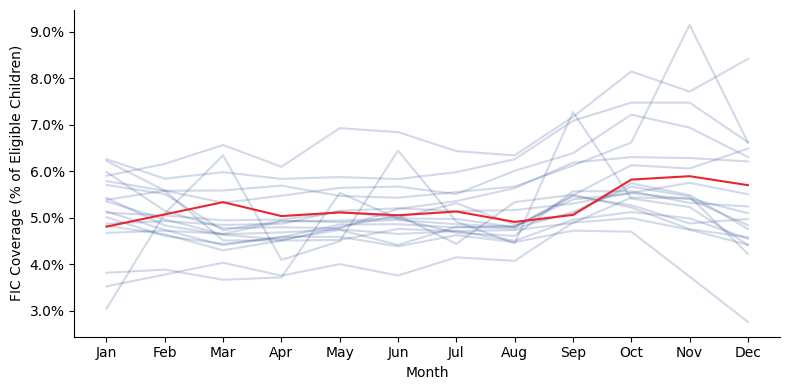

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))

for psgc, group in region_df.groupby('PSGC'):
    ax.plot(group['Month'], group['FIC_Percent'] / 100, alpha=0.2, color='#1e438c')

ax.plot(group['Month'], (region_df.groupby('Month')['FIC_Percent'].mean() / 100), color='#e9252f')
ax.set_ylabel('FIC Coverage (% of Eligible Children)')
ax.set_xlabel('Month')

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: legend (can get crowded)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()